In [1]:
import pandas as pd
import os
from tqdm import tqdm
from llm_asr_clarification.constants import SAMPLE_MEETINGS
import json

pd.set_option('display.max_colwidth', None)

AMI_PATH = '/group/jrwhitehill/amicorpus/train'
meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
TRANSCRIPT_FILE = "whisper_tiny_diarized_transcript"

df = []
for meeting_path in tqdm(meeting_paths):
    question_path = os.path.join(meeting_path, "artifacts", f"log_probs_{TRANSCRIPT_FILE}.csv")
    try:
        df.append(pd.read_csv(question_path))
    except Exception as err:
        print(f"couldnt open file {question_path}")

df = pd.concat(df, ignore_index=True)

100%|██████████| 136/136 [00:00<00:00, 275.08it/s]


In [2]:
df.head()

,Unnamed: 0,start_time,end_time,speaker,text,gt_text,rougeL,rougeL_prec,text_avg_logprob,text_sum_logprob,text_min_logprob,text_n_tokens
0,0,41,42,D,Okay.,"Okay....Okay, almost there.",0.400,1.000000,-6.96875,-13.9375,-9.1875,2
1,1,42,43,A,"I was thinking,","Okay, almost there.",0.000,0.000000,-4.84375,-19.3750,-9.3125,4
2,2,43,44,C,Okay.,Okay.,1.000,1.000000,-6.96875,-13.9375,-9.1875,2
3,3,44,46,C,I'll use the powerpoint again.,"We'll sta I'll use the PowerPoint, I guess.",0.625,0.833333,-5.75000,-46.0000,-9.3125,8
4,4,48,50,C,How was that? Was that fun?,"How was that, was that fun?",1.000,1.000000,-3.65625,-29.2500,-6.8750,8


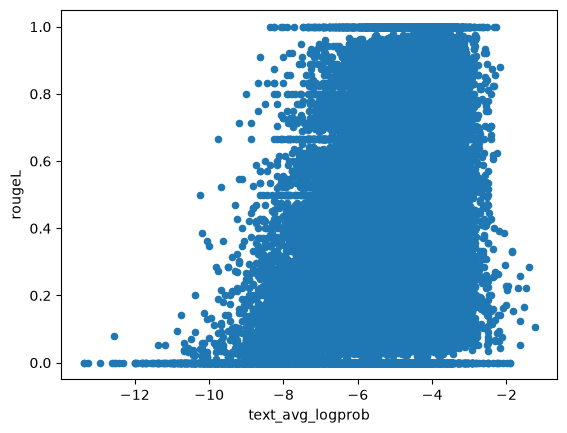

Pearson r: 0.3206
P-value: 0.0000


In [3]:
import matplotlib.pyplot as plt

df[df['text_n_tokens']>5].plot.scatter(x='text_avg_logprob', y='rougeL')

# Display the plot
plt.show()

from scipy.stats import pearsonr

result = pearsonr(df[df['text_n_tokens']>5]['text_avg_logprob'], df[df['text_n_tokens']>5]['rougeL'])

print(f"Pearson r: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

<Axes: >

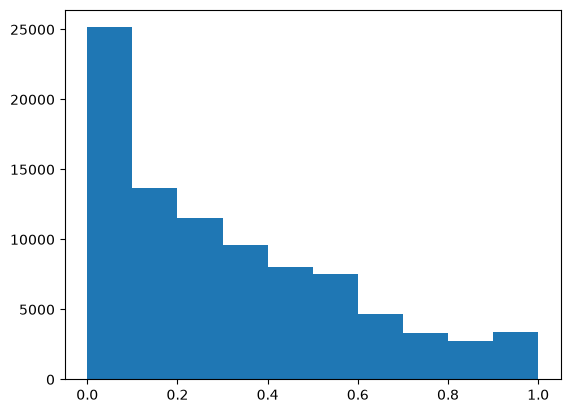

In [4]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

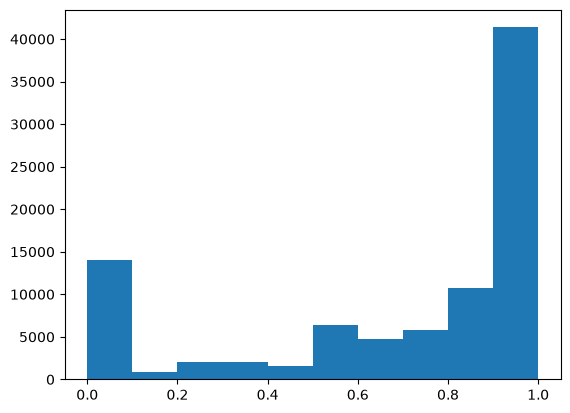

In [5]:
df['rougeL_prec'].hist(grid=False, bins=10)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["text_avg_logprob", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["text_avg_logprob"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []
    
    for thresh in thresholds:
        y_pred = (
            (df["text_avg_logprob"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [7]:
pd.set_option('display.max_colwidth', None)

# For bottom 50%

In [40]:
prec_fifty = df[df['text_n_tokens']>3]['rougeL_prec'].quantile(0.5)
print(f"50th quartile for precision is: {prec_fifty:.2f}")
rougeL_fifty = df[df['text_n_tokens']>3]['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")

50th quartile for precision is: 0.86
50th quartile for rougeL is: 0.33


In [42]:
df[(df['text_n_tokens']>3) & (df['rougeL_prec'] < prec_fifty)][['text', 'gt_text', 'rougeL_prec','rougeL']].head(10)

,text,gt_text,rougeL_prec,rougeL
1,"I was thinking,","Okay, almost there.",0.000000,0.000000
3,I'll use the powerpoint again.,"We'll sta I'll use the PowerPoint, I guess.",0.833333,0.625000
6,Yep. Very fun.,Mm.,0.000000,0.000000
8,"Oh, I forgot to mail you a few minutes.","Uh oh I've forgotten to mail you the minutes, but I will do.",0.666667,0.521739
10,"Oops, it's easy.","Uh oh I've forgotten to mail you the minutes, but I will do....Okay....Upsidaisy.",0.000000,0.000000
12,"Yeah, good.",E excuse me I forgot my copy.,0.000000,0.000000
13,All right. Okay.,"E excuse me I forgot my copy....Alright, okay, yeah.",0.333333,0.153846
14,All right. Okay.,Okay.,0.333333,0.500000
16,Good. Good.,Um Will you guys first with your prototype um before we get to the good news?,0.500000,0.111111
17,"Well, you guys are first for your prototype.",Um Will you guys first with your prototype um before we get to the good news?,0.625000,0.416667


In [38]:
df[(df['text_n_tokens']>3) & (df['rougeL_prec'] < prec_fifty)][['text', 'gt_text', 'rougeL_prec','rougeL']].sample(10)

,text,gt_text,rougeL_prec
76343,"Okay, but we leave like this.","Okay, well we leave it like this.",0.833333
86854,We've got what we do.,"Because w we only need this to work well enough that you can use it for something and you got work rats....Right, so we're we're b we're building models.",0.500000
18310,That's too shall I,Uh Uh....Shall I uh Yeah.,0.400000
64084,The second thing is the success that we should use the remote control only for TV not for DVD and of the devices because it makes it to complex and because we have no much time for this project we should stay on.,"Um the second thing is uh they suggest that that we should uh use the remote control only for T_V_, not for D_V_D_ and other devices, because it make it it makes it's too complex and uh because we have not much time for this project we should stay on T_V_ on the only specific T_V_ remote control.",0.813953
32264,"Okay, you really.","Yes....It's just a wish list....Okay, anybody Um ord base dot times.",0.333333
85799,And less we just define it as there's only the R exclusive.,Uh unle uh but it uh unless we just define it as there's only they're they are exclusive....that would Yeah.,0.692308
44571,...20 millis...,"He's starting with uh so the l left window is starts at twenty milliseconds, so so you already hear like s suppose this is full signal, you're already here.",0.000000
44210,"Maybe decoration again, they do decity or...","But if you compare no, if you compare it with some baseline, let's say you use just G_M_M_ with diagonal covariance matrices A and no decorrelation before like uh Yeah....Maybe decorrelation again they do D_C_T_ or K_L_T_ or they do that?",0.714286
40925,"Oh, no.",Yes and you can put can clip it uh on your Somewhere....Okay.,0.000000
27083,But if he said.,I can't even but if you said If you said the spectral dat The continuum's spet mm.,0.750000


In [53]:
from llm_asr_clarification.models import OracleTranscript

oracle = OracleTranscript('/group/jrwhitehill/amicorpus/train/ES2005d/transcripts/parsed_diarized_gt.txt', logger=None)
oracle.get_oracle_transcription(520, 522)

In [45]:
df[(df['text_n_tokens']>3) & (df['rougeL'] < rougeL_fifty)][['text', 'start_time', 'end_time','gt_text', 'rougeL', 'rougeL_prec']][50:60]

,text,start_time,end_time,gt_text,rougeL,rougeL_prec
189,It's a shift button.,508,511,No maybe the shift button's stuck in.,0.307692,0.400000
191,"Oh, that's fine.",518,519,"Um okay, so that would take away three, which would give us Oh that's fine....Should Uh you can do one thing.",0.296296,1.000000
192,So I don't know.,519,520,"Should Uh you can do one thing....Yeah, so we're We should fire the accountants.",0.095238,0.200000
193,I'll have a Euro 60.,520,522,"Should Uh you can do one thing....Yeah, so we're We should fire the accountants....Eleven uh eleven Euros sixty....Cool.",0.071429,0.166667
195,So we can even add some.,523,527,"Should Uh you can do one thing....Yeah, so we're We should fire the accountants....Um We cou Oh not quite, have the scroll-wheel, unfortunately....So we could even add something.",0.205128,0.666667
196,"We could, I don't quite have the scroll wheel.",527,531,"Should Uh you can do one thing....Yeah, so we're We should fire the accountants....Um We cou Oh not quite, have the scroll-wheel, unfortunately.",0.324324,0.600000
197,"Unfortunately, what?",531,532,Should Uh you can do one thing....What?,0.200000,0.500000
199,I can't.,533,535,Should Uh you can do one thing....Fire the accountants.,0.153846,0.333333
200,"Yeah, look at that.",535,540,Should Uh you can do one thing.,0.000000,0.000000
203,"Yeah, I need the arrow keys to the other.",546,549,"Should Uh you can do one thing....Maybe if you click back in that bottom right cell, where you're starting from, and then use the arrow keys....Does that work?",0.150000,0.333333


In [41]:
df[(df['text_n_tokens']>3) & (df['rougeL'] < rougeL_fifty)][['text', 'gt_text', 'rougeL', 'rougeL_prec']].sample(10)

,text,gt_text,rougeL,rougeL_prec
35869,on a remote control.,"Uh Andrew, any thoughts about uh how we might market interchangeable fronts on on the remote control?",0.285714,0.750000
76776,Pictures of fruit on...,"Spongy means it it's like sp But what's your suggestion how we can have some shape like that on the remote?...Oh, they're okay so they're not like dressed as a carrot they just have like pictures of fruit on, okay....Yeah, yeah.",0.156863,1.000000
84555,...in use when you...,"W we are aiming for younger people and they they chose So that's that's probably uh a But they Well they uh they all have to be programmed to fit your T_V_ and that that is bit of a tricky job....Well you can use um when you uh how do you call it, s um synchronized, the um remote and the T_V_, then there's always, there are always uh possibilities to change the colour and the brightness and the volume and um well maybe we can look out if there's options that the remote um in its memory can see what kinda T_V_ it is, from ah, it's a Philips, this and this and that, and then give the options that are capable the capable from the t Well there are universal d um um remotes and they all have a functionality for all the T_V_s, uh so this wouldn't be a extra feature to incorporate the men menus of these.",0.033898,0.750000
45841,Because we cannot rely 100% on these features to use the controller.,"Because the p the problem I can see with with the voice or the gesture itself wh what can happen in a family i i for example if Yeah And for all the person of the family maybe, so, yeah....Cause for example yeah....Yeah, but we do we do we we we cannot rely one hundred percent on these features to u to use the controller, but with the features of our controller such as you have the feature of voice recognition in your mobile but you seldom use it, your mobile, but you when you choose a new mobile, you choose the one with voice recognition.",0.183333,0.916667
2125,Circle or a square.,"And writing text uh, yeah, you've gotta really do your best to write some Yeah....Yeah, and and maybe some uh functions for uh uh uh circle or uh a square.",0.222222,1.000000
87925,It's quite good for the proposal.,"No, going very pra pragmatic uh there is a submission uh deadline for example thirty one December for conference on multi-media and expo where I think these two little works on So it can be It's as a proposal....But um Yeah....It's quite good for the proposal directly.",0.237288,1.000000
38221,"And as you see, it's gonna be...",Our energy source is gonna be long term.,0.250000,0.250000
24341,Speaking for it.,". Mm-hmm....It's a Well, the Yeah, but do you actually need the remote talking back?...I think if you have a a speech recognition component, then a s speaking component is not that hard to to put in either.",0.045455,0.333333
66568,Even then our product is going to be.,"Because that's with L_C_D_ just will increase the price, and I thi i they have the same rate so without L_C_D_ it will be Mm-hmm....Even then our product is going to be very good....Yeah, it's cheaper to produce.",0.290909,1.000000
41493,Ha ha ha.,"And so it comes from the P_C_, which is outside the sound-proof box....Oops.",0.000000,0.000000


Best threshold: -1.3742
Best F1: 0.6519
Precision at best F1: 0.4835
Recall at best F1: 1.0000



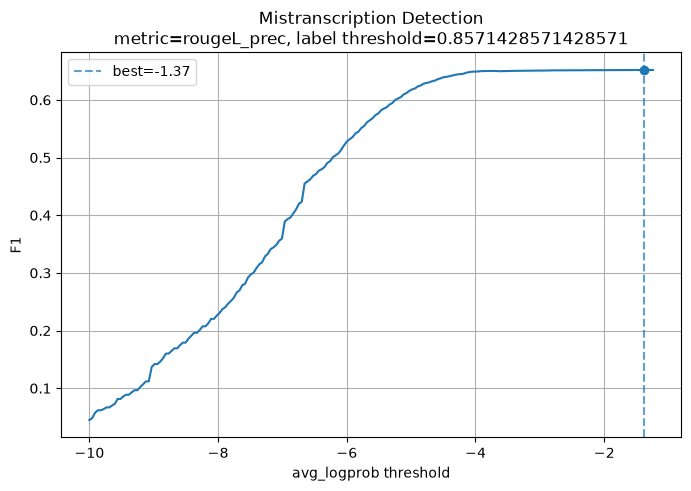

In [20]:
elbow_plot(df, metric_to_use='rougeL_prec', mistranscription_label_threshold=prec_fifty)

Best threshold: -4.5429
Best F1: 0.7539
Precision at best F1: 0.6536
Recall at best F1: 0.8906



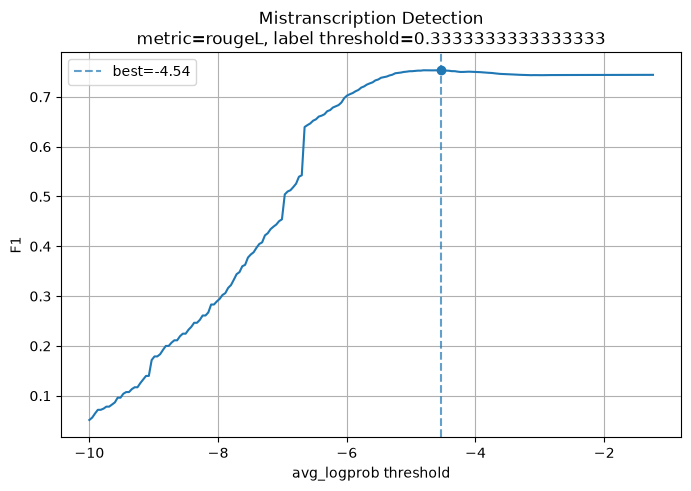

In [21]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

# For bottom 25%

In [28]:
prec_twentyfive = df[df['text_n_tokens']>3]['rougeL_prec'].quantile(0.25)
rougeL_twentyfive = df[df['text_n_tokens']>3]['rougeL'].quantile(0.25)

In [29]:
#spot checkingrouge
df[(df['text_n_tokens']>3) & (df['rougeL_prec'] < prec_twentyfive)][['text', 'gt_text', 'rougeL_prec']].head(10)

,text,gt_text,rougeL_prec
1,"I was thinking,","Okay, almost there.",0.000000
6,Yep. Very fun.,Mm.,0.000000
10,"Oops, it's easy.","Uh oh I've forgotten to mail you the minutes, but I will do....Okay....Upsidaisy.",0.000000
12,"Yeah, good.",E excuse me I forgot my copy.,0.000000
13,All right. Okay.,"E excuse me I forgot my copy....Alright, okay, yeah.",0.333333
14,All right. Okay.,Okay.,0.333333
16,Good. Good.,Um Will you guys first with your prototype um before we get to the good news?,0.500000
22,We have a bunch of problems.,Uh we have budget problems.,0.500000
24,You have a bunch of problems.,I'm afraid you're all sacked....Cutbacks....Oops.,0.166667
25,I thought you'd have this one.,I don't even have this on.,0.428571


In [30]:
#spot checkingrouge
df[(df['text_n_tokens']>3) & (df['rougeL'] < rougeL_twentyfive)][['text', 'gt_text', 'rougeL']].head(10)

,text,gt_text,rougeL
1,"I was thinking,","Okay, almost there.",0.000000
6,Yep. Very fun.,Mm.,0.000000
10,"Oops, it's easy.","Uh oh I've forgotten to mail you the minutes, but I will do....Okay....Upsidaisy.",0.000000
12,"Yeah, good.",E excuse me I forgot my copy.,0.000000
13,All right. Okay.,"E excuse me I forgot my copy....Alright, okay, yeah.",0.153846
16,Good. Good.,Um Will you guys first with your prototype um before we get to the good news?,0.111111
24,You have a bunch of problems.,I'm afraid you're all sacked....Cutbacks....Oops.,0.133333
30,You're new.,Um maybe we should bring so that the camera can see.,0.000000
37,One space under banana.,"Um one's based on the banana, one's based on the tomato and the other one is st Look.",0.166667
40,You're so tall.,"Um one's based on the banana, one's based on the tomato and the other one is st Look....What tomato?",0.000000


Best threshold: -5.5991
Best F1: 0.5092
Precision at best F1: 0.3953
Recall at best F1: 0.7154



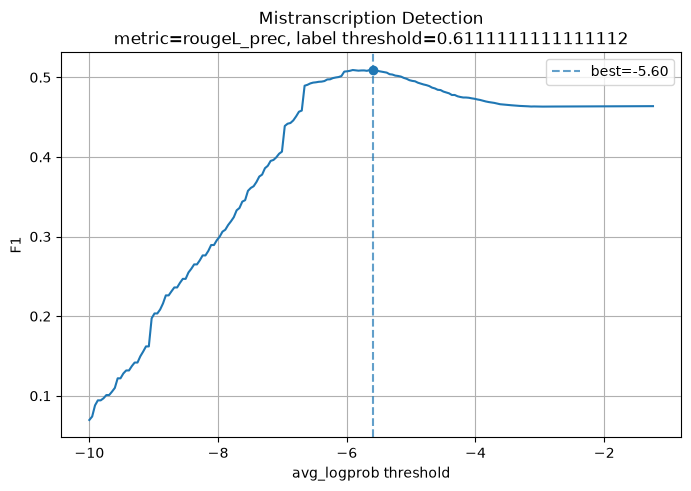

In [22]:
elbow_plot(df, metric_to_use='rougeL_prec', mistranscription_label_threshold=prec_twentyfive)

Best threshold: -6.6553
Best F1: 0.6125
Precision at best F1: 0.5195
Recall at best F1: 0.7461



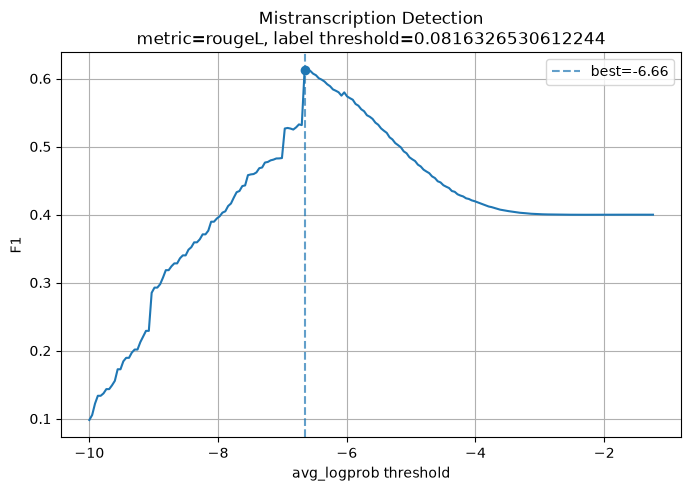

In [25]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_twentyfive)